In [1]:
from collections import Counter
import matplotlib.pyplot as plt

In [2]:

hits = []

with open('nr_hits.tsv') as inp:
    for line in inp:
        
        
        ls = line.strip().split()
        
        hit = {'pdb':ls[0],
               'size':int(ls[1]),
               'rmsd':float(ls[2]),
               'rmsdsize':float(ls[3]),
               'resrmsd':float(ls[4]),
               'matchmask':ls[5],
               'rs':ls[6:12],
               'bs':ls[12:18],
               'crystalcontacts':ls[18],
               'seqdists':[int(x) for x in ls[19:24]],
               'rels':ls[24:29],
               'elems':ls[29:35],
               'loopseq':ls[35],
               'looplen':int(ls[36]),
               'confs':ls[37:43],
               'bp25':ls[43],
               'bp16':ls[44],
               'inters':ls[45:51],
               'ut':int(ls[51]),
               'rfam':ls[52],
               'bgsu':ls[53]}
        hits.append(hit)
print(len(hits))
print(hits[0])


23283
{'pdb': 'pdb_00001a4d', 'size': 6, 'rmsd': 1.44, 'rmsdsize': 0.24, 'resrmsd': 2.295, 'matchmask': 'M111111', 'rs': ['1.A.C.71.', '1.A.G.72.', '1.B.A.101.', '1.B.G.102.', '1.B.U.103.', '1.B.G.105.'], 'bs': ['C', 'G', 'A', 'G', 'U', 'G'], 'crystalcontacts': 'M000000', 'seqdists': [1, 0, 1, 1, 2], 'rels': ['LC', 'SM', 'SM', 'SM', 'LC'], 'elems': ['S', 'IC', 'IC', 'IC', 'IC', 'S'], 'loopseq': '-', 'looplen': 0, 'confs': ["anti,~C3'-endo", "anti,~C3'-endo", "anti,~C3'-endo", "anti,~C3'-endo", "anti,~C3'-endo", "anti,~C3'-endo"], 'bp25': '-', 'bp16': 'C-G,cWW', 'inters': ['-,-', 'basepair,-', 'basepair,stack', 'basepair,-', 'basepair,-', '-,stack'], 'ut': 0, 'rfam': '-', 'bgsu': 'NR_all_66286.1'}


In [6]:
len(set([h['pdb'] for h in hits]))

3122

In [8]:
print(len(set([h['rfam'] for h in hits])))
for size in range(3,7):
    print(size, len(set([h['rfam'] for h in hits if h['size']==size])))

88
3 38
4 26
5 52
6 70


In [9]:
print(len(set([h['bgsu'] for h in hits])))
for size in range(3,7):
    print(size, len(set([h['bgsu'] for h in hits if h['size']==size])))

1063
3 321
4 228
5 622
6 679


In [11]:
Counter([tuple(h['bs']) for h in hits if any(x in h['bs'] for x in ('DG','DA','DT','DU','DC'))])

Counter({('C', 'U', 'G', 'A', '-', 'DC'): 1,
         ('DA', '-', 'DG', 'DG', 'DG', 'DG'): 1,
         ('DC', 'DG', 'DT', 'DA', 'DA', 'DG'): 1,
         ('DC', 'DA', 'DC', 'DA', '-', 'DG'): 4,
         ('C', 'G', 'DG', 'DT', 'DA', 'DG'): 1,
         ('DC', 'DG', 'DC', 'DG', 'DG', 'DC'): 1,
         ('DC', '-', 'DA', 'DG', 'DG', 'DA'): 1,
         ('DT', 'DG', 'DC', 'DA', 'DG', 'DA'): 1,
         ('DA', 'DT', 'DA', 'DA', 'DA', 'DA'): 1,
         ('DC', 'DT', 'DA', 'DA', 'DG', 'DA'): 1,
         ('DA', 'DG', 'DT', 'DG', 'DG', '-'): 1,
         ('U', 'G', 'A', 'A', 'A', 'DG'): 2,
         ('C', 'G', 'DA', '-', 'A', 'G'): 1,
         ('-', 'DA', 'DG', 'DG', 'DG', '-'): 2,
         ('DT', '-', 'DT', 'DG', 'DA', 'DA'): 1,
         ('-', 'DT', 'DA', 'DA', 'DG', '-'): 1,
         ('-', 'DA', 'DG', 'DA', 'DT', '-'): 1})

In [12]:
for size in range(3,7):
    print(size, len([1 for h in hits if h['size']==size]))

3 2569
4 1388
5 8432
6 10894


In [19]:
cnt = Counter([tuple(h['bs']) for h in hits if any(x not in {'A','C','G','U','-'} for x in h['bs'])])
print(sum(cnt.values()))
for k in sorted(cnt.keys(),key = lambda x: cnt[x],reverse = True):
    print(k,cnt[k])
unique = set(x for k in cnt for x in k) - {'A','C','G','U','-','DC','DU','DT','DA','DG'}
for x in unique:
    print(x,sum(1 for h in hits if x in h['bs']))

844
('PSU', 'U', 'G', 'A', 'A', '-') 86
('5MC', 'U', 'C', 'A', 'U', '-') 47
('OMC', 'U', 'C', 'A', 'U', '-') 45
('PSU', 'G', 'C', 'A', 'A', 'G') 38
('G', '2MG', 'G', 'MA6', 'MA6', 'C') 33
('U', 'U', 'U', 'G', '6MZ', '-') 31
('C', 'G', 'G', 'MA6', 'MA6', 'G') 29
('OMC', 'U', 'OMG', 'A', 'A', '-') 26
('U', 'G', '-', '7MG', 'A', 'A') 22
('C', 'G', 'C', 'A2M', '-', 'G') 22
('A2M', 'G', 'A', 'A', 'A', 'U') 22
('C', 'G', 'C', 'A2M', 'A', 'G') 20
('C', '-', 'G', 'G', 'A', 'OMG') 17
('G', 'G', 'G', 'MA6', 'MA6', 'C') 17
('G', '-', 'G', 'MA6', 'MA6', 'C') 13
('G', 'U', 'A', 'A2M', 'U', 'C') 13
('U', 'G', 'A', 'A', 'A2M', '-') 12
('U', 'G', 'G', 'MA6', 'MA6', 'A') 10
('C', 'G', 'C', 'A', 'A', 'OMG') 10
('G', 'U', 'G', 'MA6', 'MA6', 'C') 10
('A', '-', 'A', 'A', 'U', 'PSU') 10
('G', 'G', 'UR3', 'A', 'A', 'C') 9
('C', 'A', 'G', 'C', 'C', '7MG') 8
('C', 'G', 'U', 'A', 'A', 'OMG') 8
('A', 'G', 'A', 'A', 'A', 'PSU') 8
('A', '-', 'G', 'OMG', 'C', 'G') 7
('4AC', 'G', 'A', 'A', 'A', 'G') 7
('U', 'G', 'A'

In [20]:
for i in range(6):
    print('n'+str(i+1), sum(1 for h in hits if h['bs'][i]=='-'))

n1 4068
n2 2393
n3 2879
n4 521
n5 3038
n6 6016


In [21]:
Counter([h['matchmask'] for h in hits])

Counter({'M111111': 10894,
         'M101111': 2393,
         'M011110': 1388,
         'M111110': 2059,
         'M011100': 2167,
         'M110111': 2653,
         'M111101': 871,
         'M111011': 345,
         'M010110': 226,
         'M011010': 176,
         'M011111': 111})

In [23]:
for i in range(6):
    for b in 'ACGU':
        print('n'+str(i+1),b, sum(1 for h in hits if h['bs'][i]==b) / sum(1 for h in hits if h['bs'][i]!='-'))

n1 A 0.06411657559198543
n1 C 0.47754358574030703
n1 G 0.15347384855581578
n1 U 0.28639084048920116
n2 A 0.030493058879846817
n2 C 0.01881282910483485
n2 G 0.7202010531354716
n2 U 0.22685495452369556
n3 A 0.5745442070182317
n3 C 0.13938443442462262
n3 G 0.17717114291315428
n3 U 0.10444030582238777
n4 A 0.6526667252438274
n4 C 0.05078639838327036
n4 G 0.2504612951410245
n4 U 0.03417977330638784
n5 A 0.7777722894541862
n5 C 0.07700666831316375
n5 G 0.06613978760187701
n5 U 0.06796739935786614
n6 A 0.12654195864944692
n6 C 0.16279608501766374
n6 G 0.5933862280650952
n6 U 0.10934151850350379


In [ ]:
n1 C 0.47 n1 U 0.28
n2 G 0.72 n2 U 0.22
n3 A 0.57
n4 A 0.65 n4 G 0.25
n5 A 0.78
n6 G 0.59

In [30]:
cnt = Counter([(h['bp16']) for h in hits])
for k in sorted(cnt.keys(),key = lambda x: cnt[x],reverse = True):
    if cnt[k] >= 100:
        print(k,cnt[k])

C-G,cWW 8096
- 6781
G-C,cWW 2581
U-G,cWW 1600
U-A,cWW 1423
A-U,cWW 1027
U-U,cWW 558
U-A,tWH 438


In [35]:
cnt = Counter([(h['inters'][3]) for h in hits])
for k in sorted(cnt.keys(),key = lambda x: cnt[x],reverse = True):
    if cnt[k] >= 100:
        print(k,cnt[k])

-,- 9931
basepair,- 9489
-,stack 2568
basepair,stack 1295


processed_hits.tsv
1.044 1.016
processed_hits_UMAC.tsv
1.342 1.363
processed_hits_UAAGAN.tsv
1.232 1.311


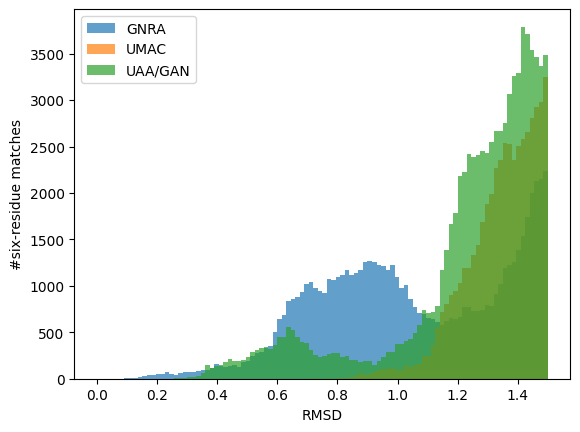

In [18]:
import matplotlib.pyplot as plt
import numpy as np
files = ("processed_hits.tsv","processed_hits_UMAC.tsv","processed_hits_UAAGAN.tsv")
labels = {"processed_hits.tsv":"GNRA","processed_hits_UMAC.tsv":"UMAC","processed_hits_UAAGAN.tsv":"UAA/GAN"}
for file in files:
    print(file)
    counts = {3:0,4:0,5:0,6:0}
    rmsds = []
    with open(file) as inp:
        for line in inp:
            ls = line.strip().split()
            size = int(ls[1])
            rmsd = float(ls[2])
            counts[size] += 1
            if size == 6 and rmsd < 100:
                rmsds.append(rmsd)
    #print(counts)
    print(round(np.mean(rmsds),3), round(np.median(rmsds),3))
    plt.hist(rmsds,bins=100,alpha=0.7,label=labels[file])
plt.legend()
plt.xlabel("RMSD")
plt.ylabel("#six-residue matches")
plt.show()